# CIFAR10 Image Classification

Fast-forward to 2012, and we move on to the deeper and more modern AlexNet architecture. We will use the CIFAR10 dataset that uses 60,000 ImageNet samples, compressed to 32x32 pixel resolution (from the original 224x224), but still with three color channels. There are only 10 of the original 1,000 classes. 

## Imports

In [1]:
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Input
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard, EarlyStopping
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras import backend as K

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
if gpu_devices:
    print('Using GPU')
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print('Using CPU')

Using CPU


In [3]:
sns.set_style('whitegrid')
np.random.seed(42)

In [4]:
results_path = Path('results', 'cifar10')
if not results_path.exists():
    results_path.mkdir()

## Load CIFAR-10 Data

CIFAR10 can also be downloaded from keras, and we similarly rescale the pixel values and one-hot encode the ten class labels. 

In [5]:
# load the pre-shuffled train and test data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


### Visualize the First 30 Training Images

In [6]:
cifar10_labels = {
    0: 'airplane',
    1: 'automobile',
    2: 'bird',
    3: 'cat',
    4: 'deer',
    5: 'dog',
    6: 'frog',
    7: 'horse',
    8: 'ship',
    9: 'truck'
}

In [7]:
num_classes = len(cifar10_labels)

In [10]:
height, width, channels = X_train.shape[1:]
input_shape = height, width, channels
input_shape

(32, 32, 3)

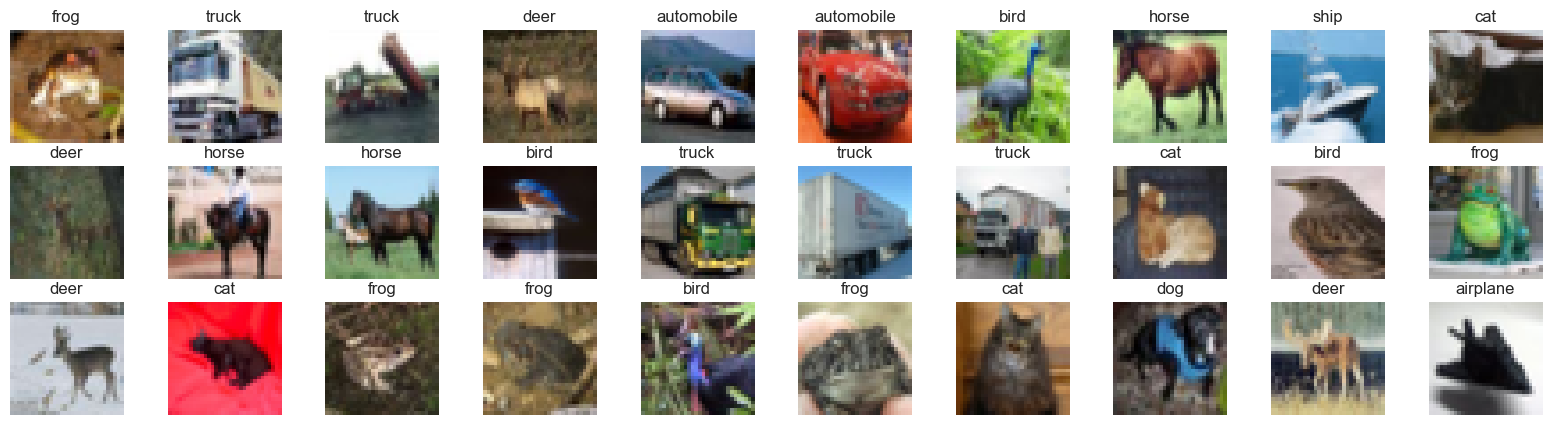

In [11]:
fig, axes = plt.subplots(nrows=3, ncols=10, figsize=(20, 5))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.imshow(np.squeeze(X_train[i]))
    ax.axis('off')
    ax.set_title(cifar10_labels[y_train[i, 0]])

### Rescale the Images

In [12]:
# rescale [0,255] --> [0,1]
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

### Train-Test split

In [13]:
X_train, X_valid = X_train[5000:], X_train[:5000]
y_train, y_valid = y_train[5000:], y_train[:5000]

In [14]:
# shape of training set
X_train.shape

(45000, 32, 32, 3)

In [15]:
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')
print(X_valid.shape[0], 'validation samples')

45000 train samples
10000 test samples
5000 validation samples


## Feedforward Neural Network

We first train a two-layer feedforward network on 50,000 training samples for training for 20 epochs to achieve a test accuracy of 44.22%. We also experiment with a three-layer convolutional net with 500K parameters for 67.07% test accuracy.

### Model Architecture 

In [17]:
mlp = Sequential([
    Input(shape=input_shape, name='input'),
    Flatten(name='flatten'),
    Dense(1000, activation='relu', name='hidden_layer_1'),
    Dropout(0.2, name='droput_1'),
    Dense(512, activation='relu', name='hidden_layer_2'),
    Dropout(0.2, name='dropout_2'),
    Dense(num_classes, activation='softmax', name='output')
])

In [18]:
mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 1000)           │     3,073,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ droput_1 (Dropout)              │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 512)            │       512,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,590,642 (13.70 MB)

 Trainable params: 3,590,642 (13.70 MB)

 Non-trainable params: 0 (0.00 B)

### Compile the Model 

In [19]:
mlp.compile(loss='sparse_categorical_crossentropy',
            optimizer='adam',
            metrics=['accuracy'])

### Define Callbacks

In [20]:
mlp_path = (results_path / 'mlp.weights.best.keras').as_posix()

In [21]:
checkpointer = ModelCheckpoint(filepath=mlp_path,
                               verbose=1,
                               monitor='val_accuracy',
                               save_best_only=True)

In [23]:
tensorboard = TensorBoard(log_dir=results_path / 'logs' / 'mlp',
                          histogram_freq=1,
                          write_graph=True,
                          write_images=False,
                          update_freq='epoch')

In [24]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=10)

### Train the Model 

In [25]:
batch_size = 32
epochs = 100

In [26]:
mlp_history = mlp.fit(X_train,
                      y_train,
                      batch_size=batch_size,
                      epochs=epochs,
                      validation_data=(X_valid, y_valid),
                      callbacks=[checkpointer, tensorboard, early_stopping],
                      verbose=1,
                      shuffle=True)

Epoch 1/100
1403/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2325 - loss: 2.1644
Epoch 1: val_accuracy improved from -inf to 0.35920, saving model to results/cifar10/mlp.weights.best.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.2326 - loss: 2.1638 - val_accuracy: 0.3592 - val_loss: 1.7953
Epoch 2/100
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3089 - loss: 1.8811
Epoch 2: val_accuracy did not improve from 0.35920
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.3089 - loss: 1.8811 - val_accuracy: 0.3294 - val_loss: 1.8536
Epoch 3/100
1405/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3235 - loss: 1.8461
Epoch 3: val_accuracy improved from 0.35920 to 0.37000, saving model to results/cifar10/mlp.weights.best.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.3235 - loss: 1.8461 - val_accuracy: 0.3700 - val_loss: 1.7286
Epoch 4/100
1405/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3429 - loss: 1.8032
Epoch 4

### Plot CV Results

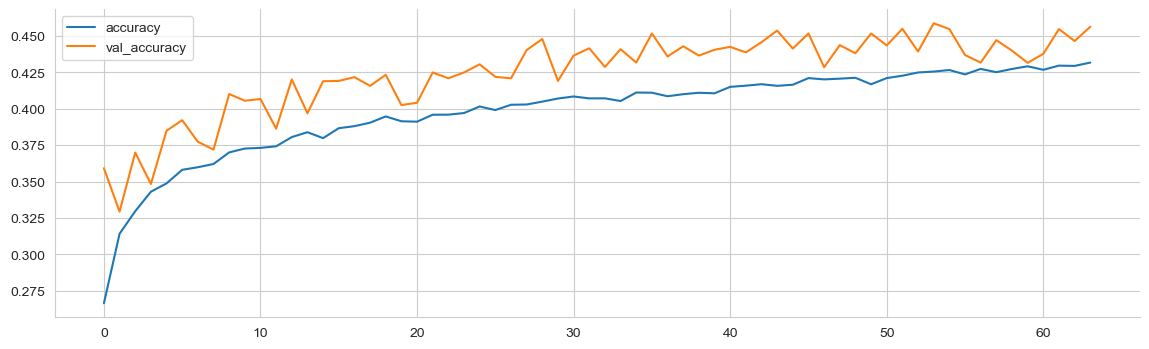

In [27]:
pd.DataFrame(mlp_history.history)[['accuracy', 'val_accuracy']].plot(figsize=(14, 4))
sns.despine()

### Load best model

In [28]:
# load the weights that yielded the best validation accuracy
mlp.load_weights(mlp_path)

### Test Classification Accuracy

In [29]:
# evaluate and print test accuracy
mlp_accuracy = mlp.evaluate(X_test, y_test, verbose=0)[1]
print('Test accuracy: {:.2%}'.format(mlp_accuracy))

Test accuracy: 44.99%


## Convolutional Neural Network

In [30]:
# https://stackoverflow.com/questions/35114376/error-when-computing-summaries-in-tensorflow/35117760#35117760
K.clear_session()

### Model Architecture

In [31]:
cnn = Sequential([
       Input(shape=input_shape),
    Conv2D(filters=16,
           kernel_size=2,
           padding='same',
           activation='relu',
           name='CONV1'),
    MaxPooling2D(pool_size=2, name='POOL1'),
    Conv2D(filters=32,
           kernel_size=2,
           padding='same',
           activation='relu',
           name='CONV2'),
    MaxPooling2D(pool_size=2, name='POOL2'),
    Conv2D(filters=64,
           kernel_size=2,
           padding='same',
           activation='relu',
           name='CONV3'),
    MaxPooling2D(pool_size=2, name='POOL3'),
    Dropout(0.3, name='DROP1'),
    Flatten(name='FLAT1'),
    Dense(500, activation='relu', name='FC1'),
    Dropout(0.4, name='DROP2'),
    Dense(10, activation='softmax', name='FC2')
])

In [32]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ CONV1 (Conv2D)                  │ (None, 32, 32, 16)     │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ POOL1 (MaxPooling2D)            │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CONV2 (Conv2D)                  │ (None, 16, 16, 32)     │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ POOL2 (MaxPooling2D)            │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CONV3 (Conv2D)                  │ (None, 8, 8, 64)       │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ POOL3 (MaxPooling2D)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DROP1 (Dropout)                 │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FLAT1 (Flatten)                 │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 500)            │       512,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DROP2 (Dropout)                 │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 528,054 (2.01 MB)

 Trainable params: 528,054 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

### Compile the Model

In [33]:
cnn.compile(loss='sparse_categorical_crossentropy',
            optimizer='adam',
            metrics=['accuracy'])

### Define Callbacks

In [34]:
cnn_path = (results_path / 'cnn.weights.best.keras').as_posix()

In [35]:
checkpointer = ModelCheckpoint(filepath=cnn_path,
                               verbose=1,
                               monitor='val_accuracy',
                               save_best_only=True)

In [36]:
tensorboard = TensorBoard(log_dir=results_path / 'logs' / 'cnn',
                          histogram_freq=1,
                          write_graph=True,
                          write_images=False,
                          update_freq='epoch')

In [37]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=10)

### Train the Model

In [38]:
batch_size = 32
epochs = 100

In [39]:
cnn_history = cnn.fit(X_train,
                      y_train,
                      batch_size=batch_size,
                      epochs=epochs,
                      validation_data=(X_valid, y_valid),
                      callbacks=[checkpointer, tensorboard, early_stopping],
                      verbose=2,
                      shuffle=True)

Epoch 1/100

Epoch 1: val_accuracy improved from -inf to 0.56780, saving model to results/cifar10/cnn.weights.best.keras
1407/1407 - 11s - 8ms/step - accuracy: 0.4303 - loss: 1.5645 - val_accuracy: 0.5678 - val_loss: 1.2228
Epoch 2/100

Epoch 2: val_accuracy improved from 0.56780 to 0.62360, saving model to results/cifar10/cnn.weights.best.keras
1407/1407 - 13s - 9ms/step - accuracy: 0.5574 - loss: 1.2377 - val_accuracy: 0.6236 - val_loss: 1.0708
Epoch 3/100

Epoch 3: val_accuracy improved from 0.62360 to 0.66420, saving model to results/cifar10/cnn.weights.best.keras
1407/1407 - 11s - 8ms/step - accuracy: 0.6038 - loss: 1.1071 - val_accuracy: 0.6642 - val_loss: 0.9819
Epoch 4/100

Epoch 4: val_accuracy improved from 0.66420 to 0.67420, saving model to results/cifar10/cnn.weights.best.keras
1407/1407 - 12s - 8ms/step - accuracy: 0.6337 - loss: 1.0288 - val_accuracy: 0.6742 - val_loss: 0.9197
Epoch 5/100

Epoch 5: val_accuracy improved from 0.67420 to 0.69280, saving model to results/ci

### Plot CV Results

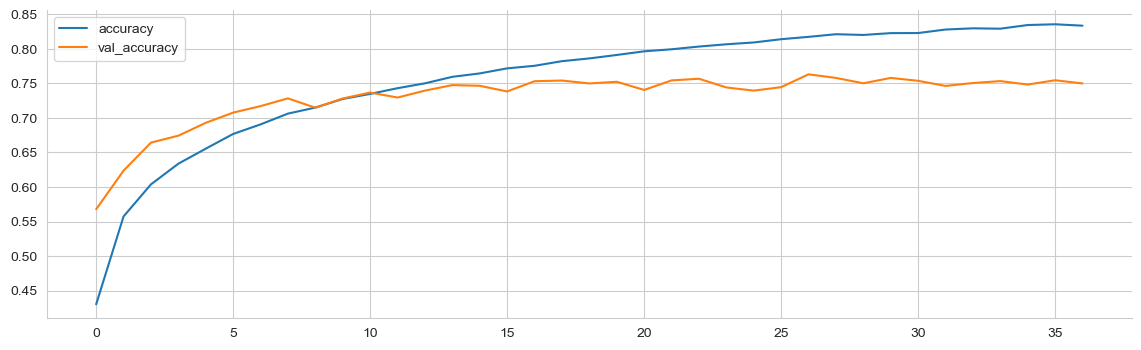

In [40]:
pd.DataFrame(cnn_history.history)[['accuracy',
                                   'val_accuracy']].plot(figsize=(14, 4))
sns.despine();

### Load best model

In [41]:
cnn.load_weights(cnn_path)

### Test set accuracy

In [42]:
cnn_accuracy = cnn.evaluate(X_test, y_test, verbose=0)[1]
print('Accuracy: {:.2%}'.format(cnn_accuracy))

Accuracy: 74.94%


### Evaluate Predictions

In [43]:
y_hat = cnn.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


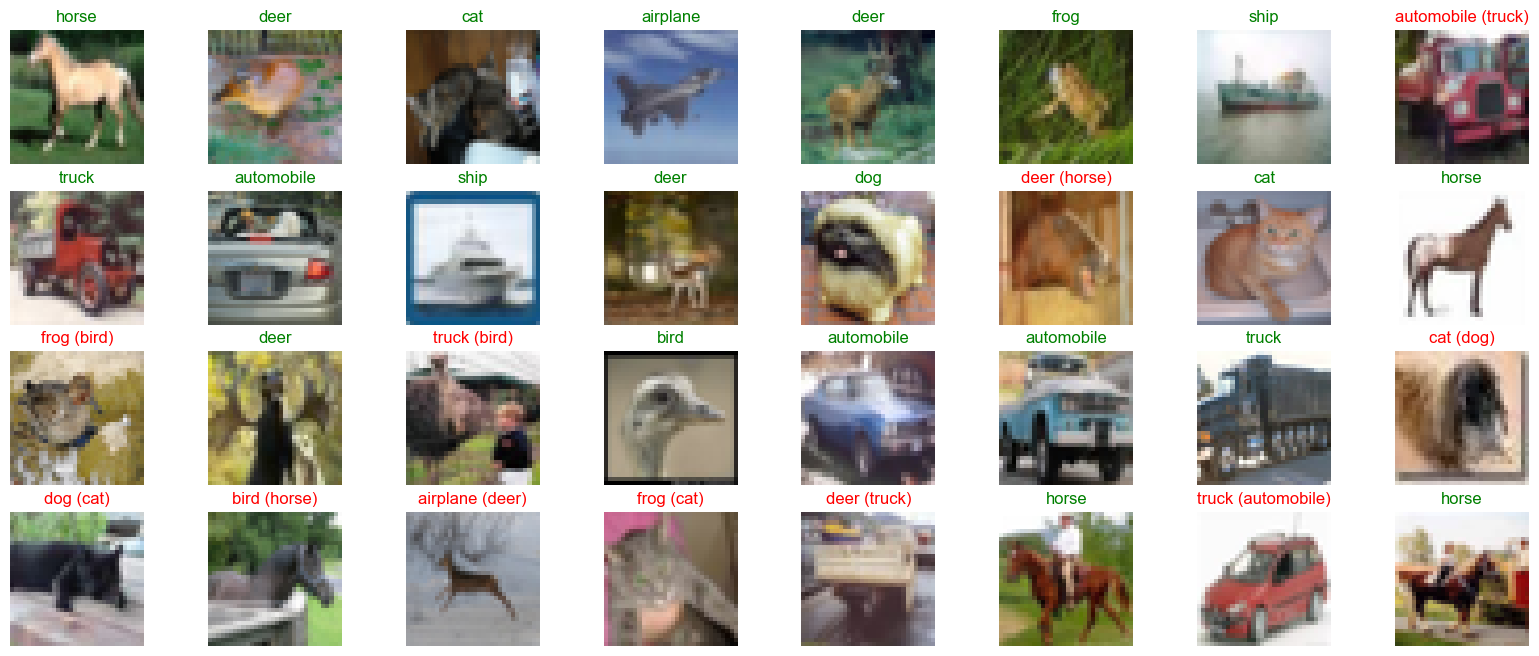

In [54]:
fig, axes = plt.subplots(nrows=4, ncols=8, figsize=(20, 8))
axes = axes.flatten()
images = np.random.choice(X_test.shape[0], size=32, replace=False)
for i, (ax, idx) in enumerate(zip(axes, images)):
    ax.imshow(np.squeeze(X_test[idx]))
    ax.axis('off')
    pred_idx, true_idx = np.argmax(y_hat[idx]), y_test[idx][0]
    if pred_idx == true_idx:
        ax.set_title('{}'.format(cifar10_labels[pred_idx]), color="green")
    else:
        ax.set_title("{} ({})".format(cifar10_labels[pred_idx],
                                      cifar10_labels[true_idx]),
                     color='red')

## CNN with Image Augmentation

A common trick to enhance performance is to artificially increase the size of the training set by creating synthetic data. This involves randomly shifting or horizontally flipping the image, or introducing noise into the image.

### Create and configure augmented image generator

Keras includes an ImageDataGenerator for this purpose that we can configure and fit to the training data as follows:

In [55]:
datagen = ImageDataGenerator(
    width_shift_range=0.1,  # randomly horizontal shift
    height_shift_range=0.1,  # randomly vertial shift
    horizontal_flip=True)  # randomly horizontalflip

In [56]:
# fit augmented image generator on data
datagen.fit(X_train)

### Visualize subset of training data

The result shows how the augmented images have been altered in various ways as expected:

In [57]:
n_images = 6
x_train_subset = X_train[:n_images]

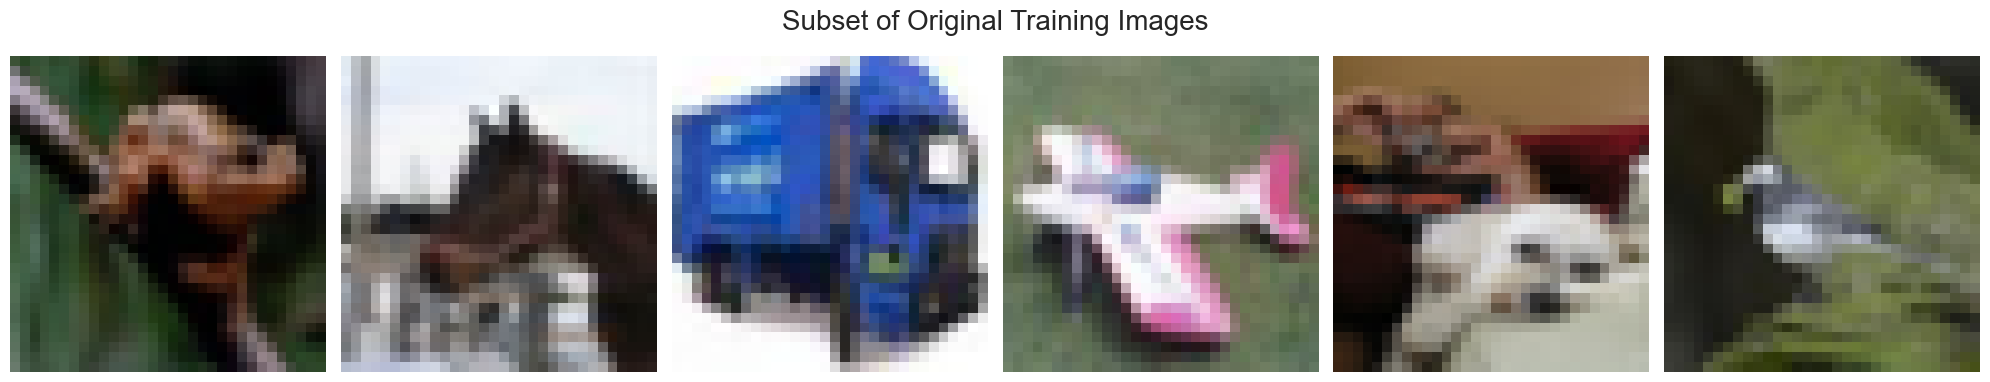

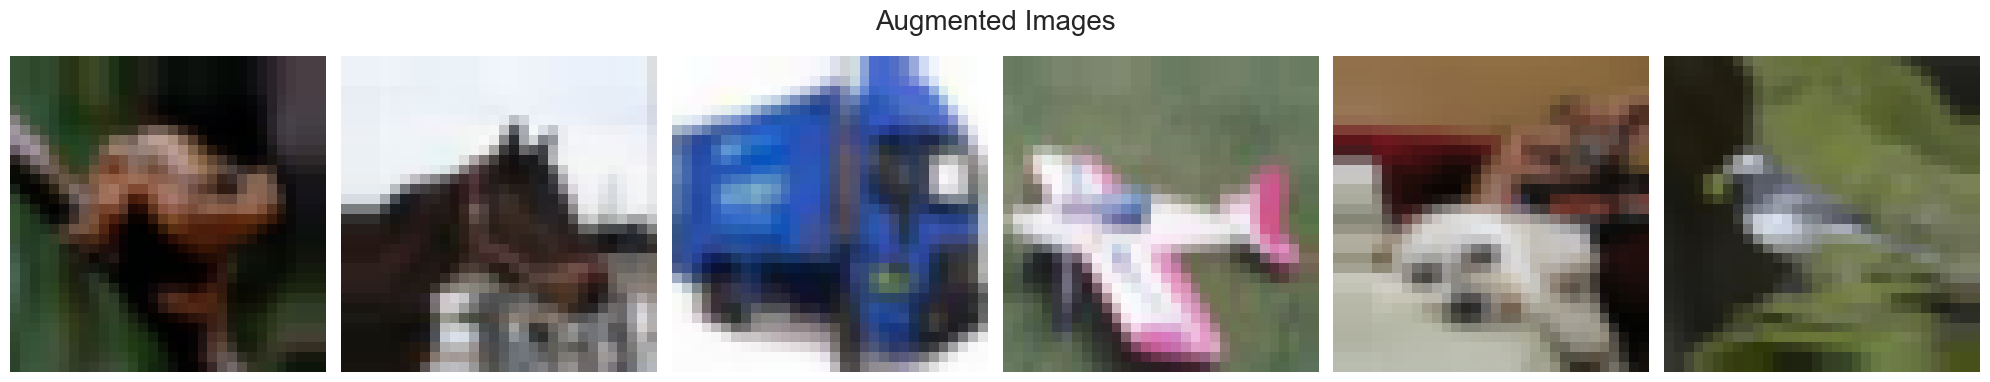

In [58]:
# original images
fig, axes = plt.subplots(nrows=1, ncols=n_images, figsize=(20, 4))
for i, (ax, img) in enumerate(zip(axes, x_train_subset)):
    ax.imshow(img)
    ax.axis('off')
fig.suptitle('Subset of Original Training Images', fontsize=20)
fig.tight_layout()
fig.subplots_adjust(top=.9)
fig.savefig(results_path / 'original_images')

# augmented images
fig, axes = plt.subplots(nrows=1, ncols=n_images, figsize=(20, 4))
for x_batch in datagen.flow(x_train_subset, batch_size=n_images,
                            shuffle=False):
    for i, ax in enumerate(axes):
        ax.imshow(x_batch[i])
        ax.axis('off')
#     fig.suptitle('Augmented Images', fontsize=20)
    break
fig.suptitle('Augmented Images', fontsize=20)
fig.tight_layout()
fig.subplots_adjust(top=.9)
fig.savefig(results_path / 'augmented_images')

### Define Callbacks

In [ ]:
# K.clear_session()

In [59]:
cnn_aug_path = (results_path / 'augmented.cnn.weights.best.keras').as_posix()

In [60]:
checkpointer = ModelCheckpoint(filepath=cnn_aug_path,
                               verbose=1,
                               monitor='val_accuracy',
                               save_best_only=True)

In [61]:
tensorboard = TensorBoard(log_dir=results_path / 'logs' / 'cnn_aug',
                          histogram_freq=1,
                          write_graph=True,
                          write_images=False,
                          update_freq='epoch')

In [62]:
early_stopping = EarlyStopping(monitor='val_accuracy', 
                               patience=10)

### Train Augmented Images

In [63]:
batch_size = 32
epochs = 100

In [66]:
train_generator = datagen.flow(X_train, y_train, batch_size=batch_size)

In [69]:
cnn_aug_history = cnn.fit(train_generator,
                          steps_per_epoch=X_train.shape[0] // batch_size,
                          epochs=epochs,
                          validation_data=(X_valid, y_valid),
                          callbacks=[checkpointer, tensorboard, early_stopping],
                          verbose=2)

Epoch 1/100


c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from 0.75400 to 0.76020, saving model to results/cifar10/augmented.cnn.weights.best.keras
1406/1406 - 19s - 14ms/step - accuracy: 0.7068 - loss: 0.8411 - val_accuracy: 0.7602 - val_loss: 0.6982
Epoch 2/100


c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.76020
1406/1406 - 0s - 345us/step - accuracy: 0.5312 - loss: 1.1706 - val_accuracy: 0.7574 - val_loss: 0.6972
Epoch 3/100


KeyboardInterrupt: 

### Plot CV Result

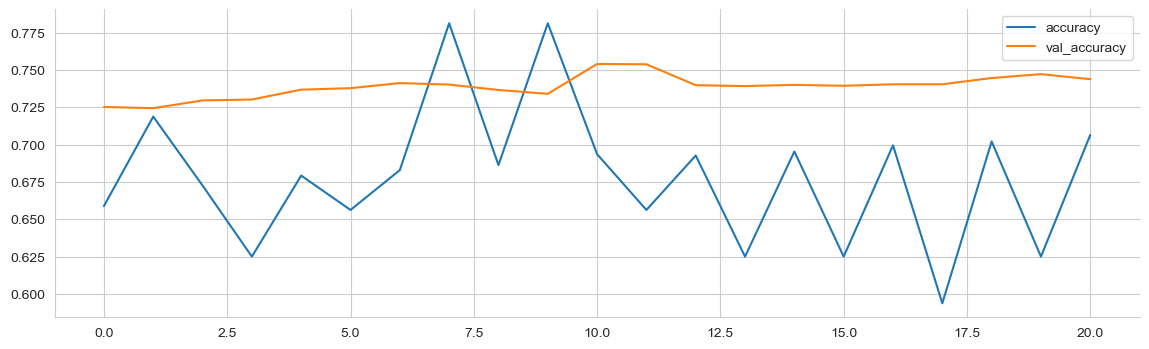

In [70]:
pd.DataFrame(cnn_aug_history.history)[['accuracy',
                                       'val_accuracy']].plot(figsize=(14, 4))
sns.despine();

### Load best model

In [71]:
cnn.load_weights(cnn_aug_path)

### Test set accuracy

The test accuracy for the three-layer CNN improves markedly to 74.79% after training on the larger, augmented data.

In [72]:
cnn_aug_accuracy = cnn.evaluate(X_test, y_test, verbose=0)[1]
print('Test Accuracy: {:.2%}'.format(cnn_aug_accuracy))

Test Accuracy: 75.25%


## AlexNet

We also need to simplify the AlexNet architecture in response to the lower dimensionality of CIFAR10 images relative to the ImageNet samples used in the competition. We use the original number of filters but make them smaller (see notebook for implementation). The summary shows the five convolutional layers followed by two fully-connected layers with frequent use of batch normalization, for a total of 21.5 million parameters:

### Define Architecture

In [73]:
K.clear_session()

In [75]:
alexnet = Sequential([
       Input(shape=input_shape),

    # 1st Convolutional Layer
    Conv2D(96, (3, 3),
           strides=(2, 2),
           activation='relu',
           padding='same',
           name='CONV_1'),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2), name='POOL_1'),
    BatchNormalization(name='NORM_1'),

    # 2nd Convolutional Layer
    Conv2D(filters=256,
           kernel_size=(5, 5),
           padding='same',
           activation='relu',
           name='CONV2'),
    MaxPooling2D(pool_size=(3, 3), strides=(2, 2), name='POOL2'),
    BatchNormalization(name='NORM_2'),

    # 3rd Convolutional Layer
    Conv2D(filters=384,
           kernel_size=(3, 3),
           padding='same',
           activation='relu',
           name='CONV3'),
    # 4th Convolutional Layer
    Conv2D(filters=384,
           kernel_size=(3, 3),
           padding='same',
           activation='relu',
           name='CONV4'),
    # 5th Convolutional Layer
    Conv2D(filters=256,
           kernel_size=(3, 3),
           padding='same',
           activation='relu',
           name='CONV5'),
    MaxPooling2D(pool_size=(3, 3), strides=(2, 2), name='POOL5'),
    BatchNormalization(name='NORM_5'),

    # Fully Connected Layers
    Flatten(name='FLAT'),
    Dense(4096, activation='relu', name='FC1'),
    Dropout(0.4, name='DROP1'),
    Dense(4096, activation='relu', name='FC2'),
    Dropout(0.4, name='DROP2'),
    Dense(num_classes, activation='softmax')
])

In [76]:
alexnet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ CONV_1 (Conv2D)                 │ (None, 16, 16, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ POOL_1 (MaxPooling2D)           │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ NORM_1 (BatchNormalization)     │ (None, 8, 8, 96)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CONV2 (Conv2D)                  │ (None, 8, 8, 256)      │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ POOL2 (MaxPooling2D)            │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ NORM_2 (BatchNormalization)     │ (None, 3, 3, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CONV3 (Conv2D)                  │ (None, 3, 3, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CONV4 (Conv2D)                  │ (None, 3, 3, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CONV5 (Conv2D)                  │ (None, 3, 3, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ POOL5 (MaxPooling2D)            │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ NORM_5 (BatchNormalization)     │ (None, 1, 1, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FLAT (Flatten)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 4096)           │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DROP1 (Dropout)                 │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DROP2 (Dropout)                 │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,592,330 (82.37 MB)

 Trainable params: 21,591,114 (82.36 MB)

 Non-trainable params: 1,216 (4.75 KB)

### Compile Model

In [77]:
alexnet.compile(loss='sparse_categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

### Define Callbacks

In [78]:
alexnet_path = (results_path / 'alexnet.weights.best.keras').as_posix()

In [79]:
checkpointer = ModelCheckpoint(filepath=alexnet_path,
                               verbose=1,
                               monitor='val_accuracy',
                               save_best_only=True)

In [80]:
tensorboard = TensorBoard(log_dir=results_path / 'logs' / 'alexnet',
                          histogram_freq=1,
                          write_graph=True,
                          write_images=False,
                          update_freq='epoch')

In [81]:
early_stopping = EarlyStopping(monitor='val_accuracy', 
                               mode='max',
                               patience=10)

### Train Model

In [82]:
batch_size = 32
epochs = 100

In [83]:
alex_history = alexnet.fit(X_train, 
                           y_train,
                           batch_size=batch_size,
                           epochs=epochs,
                           validation_data=(X_valid, 
                                            y_valid),
                           callbacks=[checkpointer, 
                                      tensorboard, 
                                      early_stopping],
                           verbose=1)

Epoch 1/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.3693 - loss: 1.8246
Epoch 1: val_accuracy improved from -inf to 0.32220, saving model to results/cifar10/alexnet.weights.best.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 154s 108ms/step - accuracy: 0.3693 - loss: 1.8244 - val_accuracy: 0.3222 - val_loss: 2.6494
Epoch 2/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5592 - loss: 1.2852
Epoch 2: val_accuracy improved from 0.32220 to 0.57440, saving model to results/cifar10/alexnet.weights.best.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 154s 109ms/step - accuracy: 0.5592 - loss: 1.2851 - val_accuracy: 0.5744 - val_loss: 1.2643
Epoch 3/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.6526 - loss: 1.0178
Epoch 3: val_accuracy improved from 0.57440 to 0.60280, saving model to results/cifar10/alexnet.weights.best.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 153s 109ms/step - accuracy: 0.6526 - loss: 1.0178 - val_accuracy: 0.6028 - val_loss: 1.2100
Epoch 4/100
1407

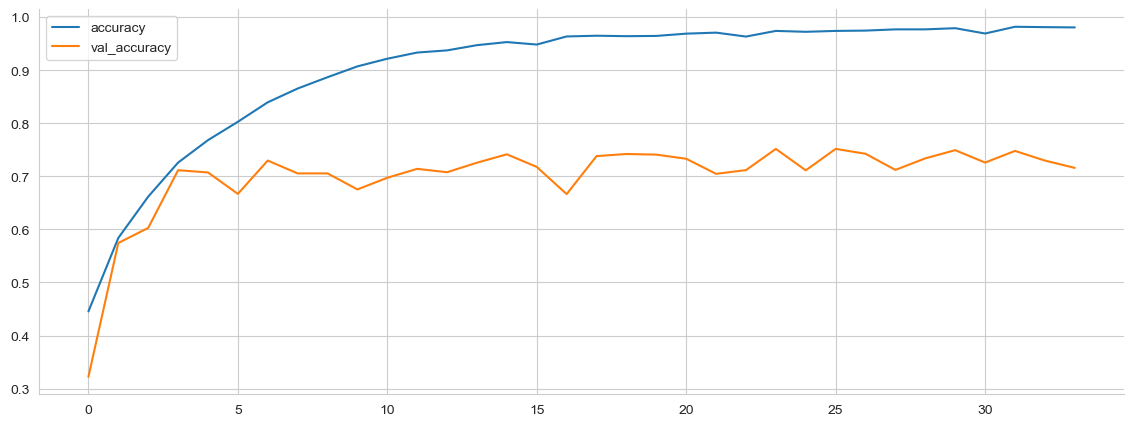

In [84]:
pd.DataFrame(alex_history.history)[['accuracy', 'val_accuracy']].plot(figsize=(14, 5))
sns.despine();

In [85]:
alexnet.load_weights(alexnet_path)

After training for 20 episodes, each of which takes a little under 30 seconds on a single GPU, we obtain 76.84% test accuracy.

In [86]:
alex_accuracy = alexnet.evaluate(X_test, y_test, verbose=0)[1]
print('Test Accuracy: {:.2%}'.format(alex_accuracy))

Test Accuracy: 72.72%


## Compare Results

In [87]:
cv_results = pd.DataFrame(
    {'Feed-Forward NN': pd.Series(mlp_history.history['val_accuracy']),
        'CNN': pd.Series(cnn_history.history['val_accuracy']),
        'CNN Aug.': pd.Series(cnn_aug_history.history['val_accuracy']),
        'Alex Net': pd.Series(alex_history.history['val_accuracy'])
    })

In [88]:
test_accuracy = pd.Series({
    'Feed-Forward NN': mlp_accuracy,
    'CNN': cnn_accuracy,
    'CNN Aug.': cnn_aug_accuracy,
    'Alex Net': alex_accuracy
})

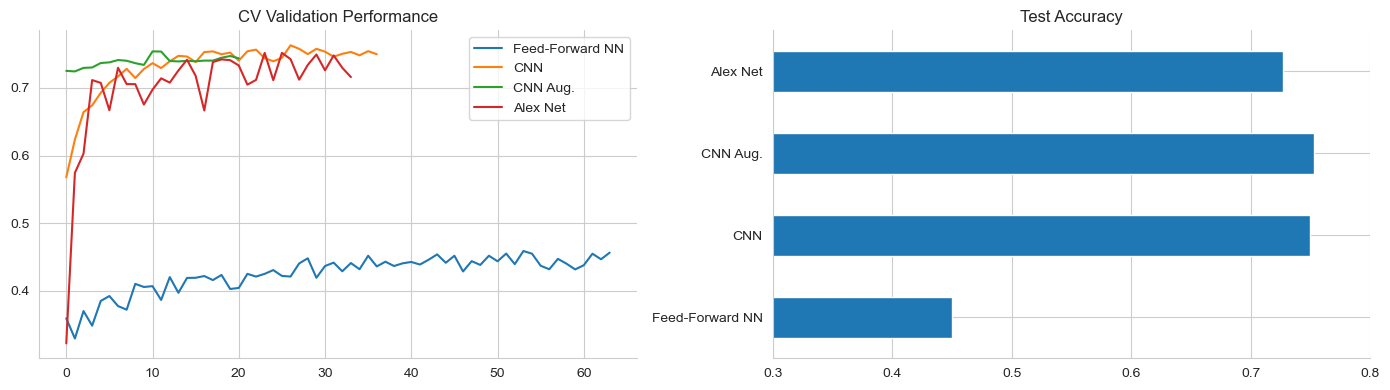

In [89]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 4))
cv_results.plot(ax=axes[0], title='CV Validation Performance')
test_accuracy.plot.barh(ax=axes[1], xlim=(.3, .8), title='Test Accuracy')
fig.tight_layout()
sns.despine()
fig.savefig(results_path / 'comparison', dpi=300);

## TensorBoard visualization

In [90]:
%load_ext tensorboard

In [92]:
%tensorboard --logdir results/cifar10/logs

Reusing TensorBoard on port 6006 (pid 23688), started 0:17:25 ago. (Use '!kill 23688' to kill it.)